# FIT3182 Assignment 2 — Task 2.2: Data Visualisation

**Student IDs:** 34080678 | 33590982

This notebook addresses **Tasks 2.2.1** and **2.2.2**:

| Sub-task | Marks | Description |
|---|---|---|
| 2.2.1 | 2 | Line charts showing violation counts and speed patterns over arrival time |
| 2.2.2 | 2 | Annotated notable points (maxima, minima, peaks, sudden changes) with operational interpretation |

### Data source priority
**MongoDB `fit3182_db.violation`** — live output written by the Spark Structured Streaming pipeline (Task 2.1).  
MongoDB must be running before executing the data-loading cell. A `RuntimeError` is raised if the connection fails or the collection is empty — there is no CSV fallback.

### Analytical questions answered
- When do violations peak across the monitoring period?
- Which camera / road segment generates the most violations?
- Are average-speed violations more common than instantaneous violations?
- Are there sudden spikes that might indicate unusual traffic behaviour?


In [1]:
from __future__ import annotations

import os
import pathlib
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from datetime import datetime, timezone
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

# Loads variables from a `.env` file (see .env.example) so connection details
# and paths don't need to be hand-edited per machine — falls back to sensible
# local-dev defaults if no .env is present (e.g. running outside Docker).
load_dotenv()

# ── Plot style ─────────────────────────────────────────────────────────────────
# Standardised sizes so every chart looks consistent.
plt.rcParams.update({
    "figure.dpi":        120,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8F9FA",
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    0.9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
    "axes.titlesize":    12,      
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,      
    "legend.fontsize":   9,       
    "xtick.labelsize":   8,       
    "ytick.labelsize":   8,       
})

# Consistent meaning across every chart.
COLOUR_INSTANT = "#E63946"   # red   — instantaneous violations / speed
COLOUR_AVERAGE = "#457B9D"   # blue  — average-speed violations / speed
COLOUR_TOTAL   = "#2A9D8F"   # teal  — combined total violations
COLOUR_SHADE   = "#F4A261"   # amber — shaded periods of interest

# Used by _ann() below so every chart has identical annotation boxes.
_ANN_BBOX  = dict(boxstyle="round,pad=0.2", fc="white", lw=0.7, alpha=0.88)
_ANN_ARROW = dict(arrowstyle="-|>", lw=1.0)


def _ann(ax, x, y, label, colour, offset=(0, 16)):
    """
    Place a compact arrow-callout annotation on *ax* at data point (x, y).

    Parameters
    ----------
    ax     : matplotlib Axes
    x      : x data coordinate
    y      : y data coordinate
    label  : annotation text
    colour : arrow and text colour (also used for box edge)
    offset : (dx_pts, dy_pts) offset of the text box from the data point
    """
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(offset[0], offset[1]),
        textcoords="offset points",
        fontsize=8,
        color=colour,
        fontweight="bold",
        arrowprops={**_ANN_ARROW, "color": colour},
        bbox={**_ANN_BBOX, "ec": colour},
        annotation_clip=False,
    )


DATA_DIR = pathlib.Path(os.getenv("DATA_DIR", "../data"))

# Camera metadata (mirrors camera.csv)
CAMERA_META = {
    1: {"speed_limit": 110, "position_km": 152.5},
    2: {"speed_limit": 110, "position_km": 153.5},
    3: {"speed_limit":  90, "position_km": 154.5},
}


def segment_distance(cam_start: int, cam_end: int) -> float:
    """Return the distance in km between two camera positions."""
    return abs(CAMERA_META[cam_end]["position_km"] - CAMERA_META[cam_start]["position_km"])


print("Imports and style configuration complete.")
print(f"matplotlib version: {matplotlib.__version__}")


Matplotlib created a temporary config/cache directory at /tmp/matplotlib-_vh2ldf0 because the default path (/home/student/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Imports and style configuration complete.
matplotlib version: 3.6.3


## Data Loading

Loads live violation data from MongoDB `fit3182_db.violation` — written by the Spark Structured Streaming pipeline (Task 2.1).

> **MongoDB must be running** before executing this cell. If the connection fails or the collection is empty, a `RuntimeError` is raised so the failure is explicit rather than silently falling back to stale data.


In [2]:
def load_from_mongo(host=None, port=None, db_name=None) -> pd.DataFrame:
    """
    Flatten the nested violation collection from MongoDB into a flat DataFrame.

    Connection defaults are read from `.env` (see .env.example) — falling back
    to the docker-compose service name `mongodb` when not set, so this works
    both inside the container network and against a locally exposed Mongo.

    Raises RuntimeError if the connection fails or the collection is empty so
    the caller gets an explicit failure rather than a silent fallback.
    """
    from pymongo import MongoClient

    host    = host    or os.getenv("MONGO_HOST", "mongodb")
    port    = port    or int(os.getenv("MONGO_PORT", "27017"))
    db_name = db_name or os.getenv("DB_NAME", "fit3182_db")

    try:
        client = MongoClient(host, port, serverSelectionTimeoutMS=3000)
        client.admin.command("ping")
    except Exception as exc:
        raise RuntimeError(
            f"Cannot connect to MongoDB at {host}:{port} — is the container running?\n"
            f"  Original error: {exc}"
        ) from exc

    col   = client[db_name]["violation"]
    count = col.count_documents({})
    if count == 0:
        client.close()
        raise RuntimeError(
            "MongoDB violation collection is empty. "
            "Run the Spark Structured Streaming pipeline (Task 2.1) first."
        )

    records = []
    for doc in col.find({}):
        for v in doc.get("violations", []):
            records.append({
                "car_plate":       doc["car_plate"],
                "date":            doc["date"],
                "violation_type":  v.get("violation_type", "UNKNOWN"),
                "camera_id_start": int(v.get("camera_id_start", 0)),
                "camera_id_end":   int(v.get("camera_id_end", 0)),
                "timestamp_start": v.get("timestamp_start"),
                "timestamp_end":   v.get("timestamp_end"),
                "speed_reading":   float(v.get("speed_reading", 0)),
                "avg_speed":       float(v.get("avg_speed", v.get("speed_reading", 0))),
            })
    client.close()

    df = pd.DataFrame(records)
    df["timestamp_start"] = pd.to_datetime(df["timestamp_start"], utc=True)
    df["timestamp_end"]   = pd.to_datetime(df["timestamp_end"],   utc=True)
    print(f"Loaded {len(df)} violation events from MongoDB ({count} daily documents).")
    return df


# ── Load from MongoDB (required — no CSV fallback) ────────────────────────────
df = load_from_mongo()

# Normalise timezone: make timestamp_start tz-naive for uniform plotting
if df["timestamp_start"].dt.tz is not None:
    df["timestamp_start"] = df["timestamp_start"].dt.tz_localize(None)
if df["timestamp_end"].dt.tz is not None:
    df["timestamp_end"] = df["timestamp_end"].dt.tz_localize(None)

print(f"\nDataset summary")
print(f"  Total violations   : {len(df):,}")
print(f"  Date range         : {df['timestamp_start'].min().date()} → {df['timestamp_start'].max().date()}")
print(f"  Violation types    : {df['violation_type'].value_counts().to_dict()}")
print(f"  Speed (km/h)       : min={df['speed_reading'].min():.1f}  "
      f"mean={df['speed_reading'].mean():.1f}  max={df['speed_reading'].max():.1f}")


Loaded 1790 violation events from MongoDB (472 daily documents).

Dataset summary
  Total violations   : 1,790
  Date range         : 2024-01-01 → 2024-01-02
  Violation types    : {'INSTANTANEOUS': 1066, 'AVERAGE': 724}
  Speed (km/h)       : min=86.7  mean=129.7  max=182.6


In [3]:

# ── Adaptive time-grouping ────────────────────────────────────────────────────
# Choose grouping frequency based on the data time-span.
#   < 1 day   → by minute
#   < 7 days  → by hour
#   < 180 days→ by day
#   < 5 years → by month
#   otherwise → by year

span_days = (df["timestamp_start"].max() - df["timestamp_start"].min()).days

if span_days < 1:
    FREQ, FREQ_LABEL, DATE_FMT = "min",  "Minute",  "%H:%M"
elif span_days < 7:
    FREQ, FREQ_LABEL, DATE_FMT = "h",   "Hour",    "%b %d %H:%M"
elif span_days < 180:
    FREQ, FREQ_LABEL, DATE_FMT = "D",   "Day",     "%d %b %Y"
elif span_days < 5 * 365:
    FREQ, FREQ_LABEL, DATE_FMT = "ME",  "Month",   "%b %Y"
else:
    FREQ, FREQ_LABEL, DATE_FMT = "YE",  "Year",    "%Y"

print(f"Time span: {span_days} days  →  grouping by {FREQ_LABEL} (freq='{FREQ}')")

# ── Pre-build per-type time series ───────────────────────────────────────────
df["period"] = df["timestamp_start"].dt.to_period(FREQ).dt.to_timestamp()

inst = df[df["violation_type"] == "INSTANTANEOUS"]
avg  = df[df["violation_type"] == "AVERAGE"]

# Violation counts per period
count_inst  = inst.groupby("period").size().rename("count")
count_avg   = avg.groupby("period").size().rename("count")
count_total = df.groupby("period").size().rename("count")

# Average speed per period (rolling 3-period smooth for clarity)
speed_inst  = inst.groupby("period")["speed_reading"].mean()
speed_avg   = avg.groupby("period")["avg_speed"].mean()

def _smooth(series, window=3):
    return series.rolling(window, min_periods=1, center=True).mean()

print(f"\nPeriods with violations  : {len(count_total)}")
print(f"  INSTANTANEOUS periods  : {len(count_inst)}")
print(f"  AVERAGE periods        : {len(count_avg)}")
print(f"  Peak total count       : {count_total.max()} (at {count_total.idxmax().strftime(DATE_FMT)})")


Time span: 0 days  →  grouping by Minute (freq='min')

Periods with violations  : 83
  INSTANTANEOUS periods  : 83
  AVERAGE periods        : 53
  Peak total count       : 68 (at 16:00)


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Visualisation Toggles
#  ─────────────────────
#  Set these flags before running cells to control what is plotted and whether
#  live MongoDB polling is active.
#
#  LIVE_MODE = False  →  Run All Cells produces static assessed outputs only.
#  LIVE_MODE = True   →  Run the live monitoring cell MANUALLY to start polling.
#                        Never enable via Run All — it blocks the kernel.
# ═══════════════════════════════════════════════════════════════════════════════

# ── Chart visibility ──────────────────────────────────────────────────────────
SHOW_VIOLATION_COUNT     = True   # Chart 1 — Violation Count Over Time
SHOW_SPEED_OVER_TIME     = True   # Chart 2 — Average Violation Speed Over Time
SHOW_DISTRIBUTION        = True   # Chart 3 — Violation Distribution by Camera / Segment
SHOW_STACKED_COMPOSITION = True   # Chart 4 — Violation Type Composition Over Time

# ── Live monitoring (optional) ────────────────────────────────────────────────
LIVE_MODE      = True  # Keep False for assessed static run; set True for live polling
POLL_INTERVAL  = 5       # seconds between MongoDB refreshes
MAX_ITERATIONS = 120     # safety cap: 120 × 5 s = 10 minutes of live polling
LIVE_SAVE_DIR  = "."     # directory where live-refresh PNGs are saved (separate from static)

print("Toggle configuration:")
print(f"  LIVE_MODE               = {LIVE_MODE}")
print(f"  SHOW_VIOLATION_COUNT    = {SHOW_VIOLATION_COUNT}")
print(f"  SHOW_SPEED_OVER_TIME    = {SHOW_SPEED_OVER_TIME}")
print(f"  SHOW_DISTRIBUTION       = {SHOW_DISTRIBUTION}")
print(f"  SHOW_STACKED_COMPOSITION= {SHOW_STACKED_COMPOSITION}")


Toggle configuration:
  LIVE_MODE               = True
  SHOW_VIOLATION_COUNT    = True
  SHOW_SPEED_OVER_TIME    = True
  SHOW_DISTRIBUTION       = True
  SHOW_STACKED_COMPOSITION= True


## Chart 1 — Violation Count Over Time

**Operational question:** *When do violations peak, and is there a noticeable difference between instantaneous and average-speed violations over time?*

Each data point represents the number of confirmed violations recorded within one time period. Three series are plotted:
- **Total** violations (teal area)
- **Instantaneous** violations (red dashed)
- **Average-speed** violations (blue dash-dot)

Annotated points: global maximum (peak), global minimum (trough), and the largest single-period surge (greatest consecutive-period increase).
The amber-shaded region highlights the top 10% of highest-volume periods.


Saved: violation_count_over_time.png


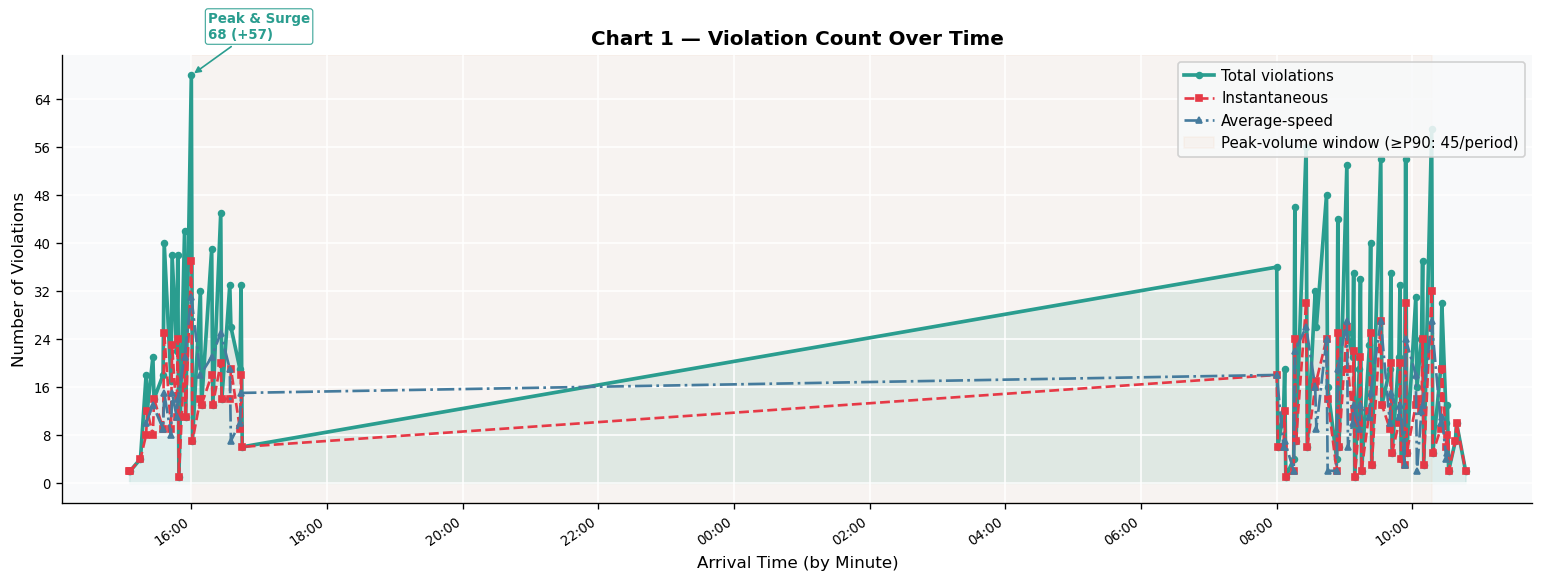

In [5]:
def plot_violation_count(
    count_total_s: "pd.Series",
    count_inst_s: "pd.Series",
    count_avg_s: "pd.Series",
    freq_label: str,
    date_fmt: str,
    save_path: str = "violation_count_over_time.png",
    show: bool = True,
) -> "plt.Figure":
    """
    Chart 1 — Violation Count Over Time.

    Plots total, instantaneous, and average-speed violation counts per time period.
    Annotates the global peak, trough, and largest surge (3 annotations max).
    Shades only the top-10% highest-volume periods to keep the region intentional.

    Parameters
    ----------
    count_total_s : total violations per period
    count_inst_s  : instantaneous violations per period
    count_avg_s   : average-speed violations per period
    freq_label    : human-readable grouping frequency (e.g. "Day")
    date_fmt      : strftime format for x-axis labels
    save_path     : output PNG path (None to skip saving)
    show          : whether to call plt.show()
    """
    fig, ax = plt.subplots(figsize=(13, 5))

    all_periods = count_total_s.index

    # ── Main data series ───────────────────────────────────────────────────────
    ax.fill_between(all_periods, count_total_s.values,
                    alpha=0.12, color=COLOUR_TOTAL, label="_nolegend_")
    ax.plot(all_periods, count_total_s.values,
            color=COLOUR_TOTAL, lw=2.2, marker="o", ms=3.5, label="Total violations")

    if not count_inst_s.empty:
        ax.plot(count_inst_s.index, count_inst_s.values,
                color=COLOUR_INSTANT, lw=1.6, ls="--", marker="s", ms=3.5,
                label="Instantaneous")

    if not count_avg_s.empty:
        ax.plot(count_avg_s.index, count_avg_s.values,
                color=COLOUR_AVERAGE, lw=1.6, ls="-.", marker="^", ms=3.5,
                label="Average-speed")

    # ── Shaded region: top-10% periods only (intentional, not half the chart) ──
    q90 = count_total_s.quantile(0.90)
    high_vol = count_total_s[count_total_s >= q90]
    if len(high_vol) >= 1 and len(all_periods) > 1:
        ax.axvspan(high_vol.index.min(), high_vol.index.max(),
                   alpha=0.06, color=COLOUR_SHADE,
                   label=f"Peak-volume window (≥P90: {q90:.0f}/period)")

    # ── Helper: determine left/right half position ─────────────────────────────
    def _side(idx):
        pos = list(all_periods).index(idx) if idx in all_periods else 0
        return "left" if pos < len(all_periods) / 2 else "right"

    # ── Annotation 1: global peak ──────────────────────────────────────────────
    peak_t = count_total_s.idxmax()
    peak_v = int(count_total_s.max())
    # Push annotation to the right of the point if near the left edge
    off_pk = (10, 22) if _side(peak_t) == "left" else (-90, 22)
    _ann(ax, peak_t, peak_v, f"Peak: {peak_v}", COLOUR_TOTAL, offset=off_pk)

    # ── Annotation 2: global trough (non-zero) ─────────────────────────────────
    nonzero = count_total_s[count_total_s > 0]
    if len(nonzero) > 1:
        min_t = nonzero.idxmin()
        min_v = int(nonzero.min())
        if min_t != peak_t:
            off_mn = (10, -30) if _side(min_t) == "left" else (-90, -30)
            _ann(ax, min_t, min_v, f"Trough: {min_v}", "#777777", offset=off_mn)

    # ── Annotation 3: largest surge (skip if coincides with peak) ─────────────
    delta = count_total_s.diff()
    if not delta.dropna().empty and delta.dropna().max() > 0:
        surge_t = delta.idxmax()
        surge_v = int(count_total_s[surge_t])
        surge_dv = int(delta[surge_t])
        if surge_t == peak_t:
            # Merge into a combined peak+surge label to avoid overlap
            ax.texts.clear()  # remove the plain peak annotation placed above
            _ann(ax, peak_t, peak_v,
                 f"Peak & Surge\n{peak_v} (+{surge_dv})",
                 COLOUR_TOTAL, offset=off_pk)
        else:
            off_sp = (10, 22) if _side(surge_t) == "left" else (-90, 22)
            _ann(ax, surge_t, surge_v,
                 f"Surge +{surge_dv}", "#E76F51", offset=off_sp)

    # ── Formatting ─────────────────────────────────────────────────────────────
    ax.set_title("Chart 1 — Violation Count Over Time")
    ax.set_xlabel(f"Arrival Time (by {freq_label})")
    ax.set_ylabel("Number of Violations")
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    # Legend in upper-right keeps it away from the early spike at the left edge
    ax.legend(loc="upper right", framealpha=0.88, fontsize=9,
              handlelength=2.0, handletextpad=0.5)
    fig.autofmt_xdate(rotation=35, ha="right")
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=120)
        print(f"Saved: {save_path}")
    if show:
        plt.show()
    return fig


# ── Static assessed output ────────────────────────────────────────────────────
if SHOW_VIOLATION_COUNT:
    plot_violation_count(
        count_total, count_inst, count_avg,
        FREQ_LABEL, DATE_FMT,
        save_path="violation_count_over_time.png",
        show=True,
    )


## Chart 2 — Average Violation Speed Over Time

**Operational question:** *Are violations getting faster over time? Do average-speed violations differ significantly from instantaneous ones in terms of recorded speed?*

Each point is the mean recorded speed of violations in that period, with a 3-period centred rolling average smoothing applied to reduce noise.
Raw traces are drawn at low opacity; smoothed traces are drawn in full colour to highlight long-term trends.
Annotated points: all-time maximum recorded speed, minimum recorded speed, and the period with the greatest speed drop (potential traffic calming event or enforcement change).


Saved: violation_speed_over_time.png


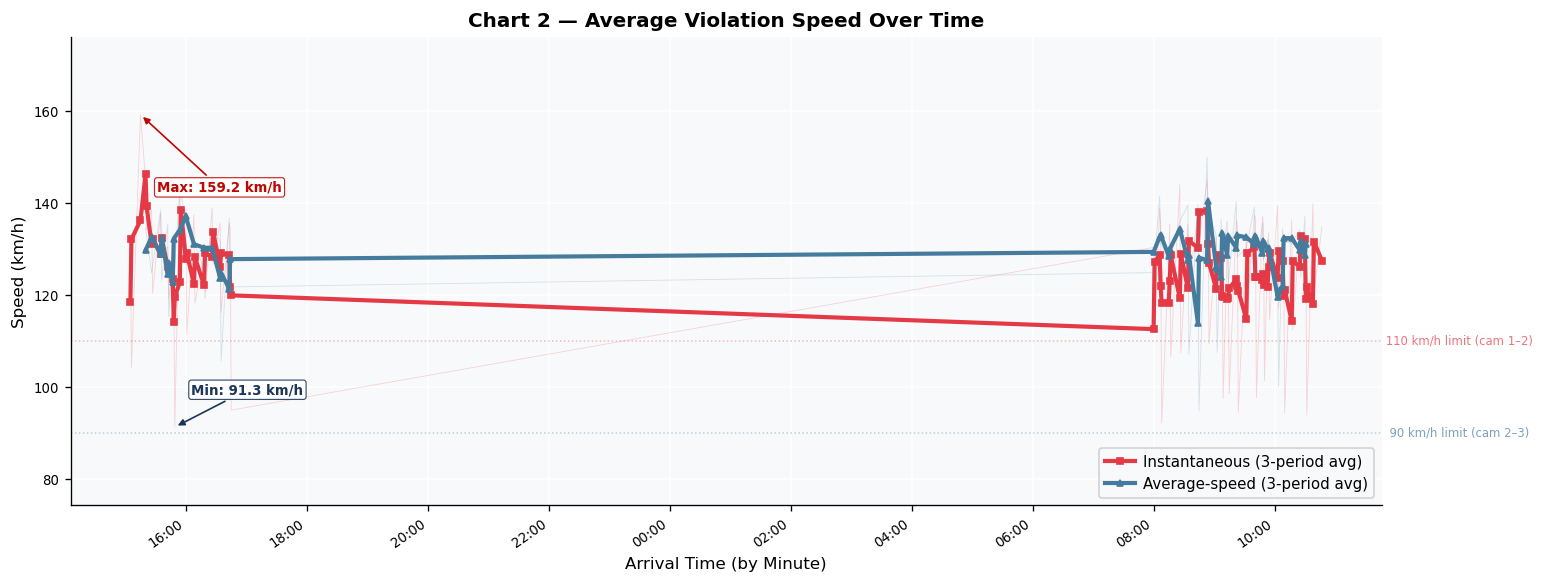

In [6]:
def plot_speed_over_time(
    df_src: "pd.DataFrame",
    speed_inst_s: "pd.Series",
    speed_avg_s: "pd.Series",
    freq_label: str,
    date_fmt: str,
    save_path: str = "violation_speed_over_time.png",
    show: bool = True,
) -> "plt.Figure":
    """
    Chart 2 — Average Violation Speed Over Time.

    Plots mean violation speed per period for instantaneous and average-speed
    violations. Raw traces are faint; smoothed (3-period) traces are prominent.
    Y-axis is tightened to the actual data range so variation is visible.
    Annotates the global max and min speeds.

    Speed-limit reference lines are drawn only when they fall within the visible
    y-range. When all violations already exceed the speed limits (as expected)
    a compact info box is shown instead.

    Parameters
    ----------
    df_src       : full violations DataFrame (used for percentile stats)
    speed_inst_s : mean instantaneous speed per period
    speed_avg_s  : mean average speed per period
    freq_label   : human-readable grouping frequency (e.g. "Day")
    date_fmt     : strftime format for x-axis labels
    save_path    : output PNG path (None to skip saving)
    show         : whether to call plt.show()
    """
    fig, ax = plt.subplots(figsize=(13, 5))

    # ── Collect all speed values to determine y-axis range ─────────────────────
    all_speeds = pd.concat([s for s in (speed_inst_s, speed_avg_s) if not s.empty])
    if all_speeds.empty:
        ax.text(0.5, 0.5, "No speed data available",
                transform=ax.transAxes, ha="center", va="center", fontsize=12)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, bbox_inches="tight", dpi=120)
        if show:
            plt.show()
        return fig

    data_min = float(all_speeds.min())
    data_max = float(all_speeds.max())
    y_pad    = max((data_max - data_min) * 0.25, 5.0)   # at least 5 km/h padding
    y_lo     = data_min - y_pad
    y_hi     = data_max + y_pad

    # ── Speed limit reference lines ────────────────────────────────────────────
    # Only draw within the visible y-range.
    # When all violations already exceed the speed limits (which is expected —
    # violations are by definition above the limit), show a compact info box.
    any_limit_visible = any(y_lo <= lim <= y_hi for lim in (110, 90))

    if any_limit_visible:
        for limit, label in ((110, "110 km/h limit (cam 1–2)"),
                             (90,  " 90 km/h limit (cam 2–3)")):
            colour = COLOUR_INSTANT if limit == 110 else COLOUR_AVERAGE
            if y_lo <= limit <= y_hi:
                ax.axhline(limit, color=colour, ls=":", lw=0.9, alpha=0.35)
                ax.annotate(
                    f" {label}",
                    xy=(1.0, limit), xycoords=("axes fraction", "data"),
                    fontsize=7, color=colour, va="center", alpha=0.7,
                    annotation_clip=False,
                )
    else:
        # All speed limits below data range — show compact info text inside chart
        ax.text(
            0.01, 0.04,
            "Speed limits:\n  Cam 1–2: 110 km/h\n  Cam 2–3:  90 km/h",
            transform=ax.transAxes, fontsize=7, color="#555", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75, lw=0.5),
        )

    # ── Raw + smoothed traces ──────────────────────────────────────────────────
    # Raw: very faint (lw=0.5, alpha=0.2) so the smoothed line is the main signal.
    # Smoothed: thick and opaque (lw=2.5).
    series_cfg = [
        (speed_inst_s, COLOUR_INSTANT, "s", "Instantaneous (3-period avg)"),
        (speed_avg_s,  COLOUR_AVERAGE, "^", "Average-speed (3-period avg)"),
    ]
    for s, colour, marker, lbl in series_cfg:
        if s.empty:
            continue
        ax.plot(s.index, s.values, color=colour, lw=0.5, alpha=0.2)
        sm = _smooth(s)
        ax.plot(sm.index, sm.values, color=colour, lw=2.5, marker=marker, ms=4,
                label=lbl)

    # ── Annotations — global max and min ──────────────────────────────────────
    gmax_v, gmax_t = None, None
    gmin_v, gmin_t = None, None

    for s, _, _, _ in series_cfg:
        if s.empty:
            continue
        vm, tm = float(s.max()), s.idxmax()
        vn, tn = float(s.min()), s.idxmin()
        if gmax_v is None or vm > gmax_v:
            gmax_v, gmax_t = vm, tm
        if gmin_v is None or vn < gmin_v:
            gmin_v, gmin_t = vn, tn

    if gmax_t is not None:
        half = "left"
        try:
            pos = list(speed_inst_s.index).index(gmax_t) if gmax_t in speed_inst_s.index \
                  else list(speed_avg_s.index).index(gmax_t)
            half = "left" if pos < len(speed_inst_s) / 2 else "right"
        except (ValueError, ZeroDivisionError):
            pass
        off_max = (10, -46) if half == "left" else (-105, -46)
        _ann(ax, gmax_t, gmax_v,
             f"Max: {gmax_v:.1f} km/h", "#BF0603", offset=off_max)

    if gmin_t is not None and gmin_t != gmax_t:
        half = "left"
        try:
            pos = list(speed_inst_s.index).index(gmin_t) if gmin_t in speed_inst_s.index \
                  else list(speed_avg_s.index).index(gmin_t)
            half = "left" if pos < len(speed_inst_s) / 2 else "right"
        except (ValueError, ZeroDivisionError):
            pass
        off_min = (10, 20) if half == "left" else (-105, 20)
        _ann(ax, gmin_t, gmin_v,
             f"Min: {gmin_v:.1f} km/h", "#1D3557", offset=off_min)

    # ── Sharpest drop annotation ──────────────────────────────────────────────
    bd_dv, bd_t, bd_v = 0.0, None, None
    for s, _, _, _ in series_cfg:
        if s.empty or len(s) < 2:
            continue
        d   = s.diff()
        pos = int(d.values.argmin())
        dv  = float(d.iloc[pos])
        if dv < bd_dv:
            bd_dv = dv
            bd_t  = s.index[pos]
            bd_v  = float(s.iloc[pos])

    if bd_t is not None and gmin_t is not None and bd_t != gmin_t:
        try:
            pos = list(speed_inst_s.index).index(bd_t) if bd_t in speed_inst_s.index \
                  else list(speed_avg_s.index).index(bd_t)
            half = "left" if pos < len(speed_inst_s) / 2 else "right"
        except (ValueError, ZeroDivisionError):
            half = "left"
        off_dr = (10, 22) if half == "left" else (-105, 22)
        _ann(ax, bd_t, bd_v, f"Drop: {bd_dv:.1f} km/h", "#E76F51", offset=off_dr)

    # ── Tighten y-axis to actual data range ────────────────────────────────────
    ax.set_ylim(y_lo, y_hi)

    # ── Formatting ─────────────────────────────────────────────────────────────
    ax.set_title("Chart 2 — Average Violation Speed Over Time")
    ax.set_xlabel(f"Arrival Time (by {freq_label})")
    ax.set_ylabel("Speed (km/h)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
    ax.legend(loc="lower right", framealpha=0.88, fontsize=9,
              handlelength=2.0, handletextpad=0.5)
    fig.autofmt_xdate(rotation=35, ha="right")
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=120)
        print(f"Saved: {save_path}")
    if show:
        plt.show()

    global combined_speed
    combined_speed = pd.concat([speed_inst_s, speed_avg_s])
    return fig


# ── Static assessed output ────────────────────────────────────────────────────
if SHOW_SPEED_OVER_TIME:
    plot_speed_over_time(
        df, speed_inst, speed_avg,
        FREQ_LABEL, DATE_FMT,
        save_path="violation_speed_over_time.png",
        show=True,
    )


## Chart 3 — Violation Distribution by Camera and Road Segment

**Operational question:** *Which camera or segment generates the most violations? Should enforcement resources be redistributed?*

Left panel — instantaneous violation counts broken down by the recording camera.
Right panel — average-speed violation counts broken down by road segment (A→B = cameras 1–2, B→C = cameras 2–3).

Each bar is labelled with its count. The dominant camera and dominant segment are highlighted with a coloured border and an analytical callout arrow stating the dominance percentage, allowing immediate identification of the highest-risk zone.


Saved: violation_by_camera_segment.png


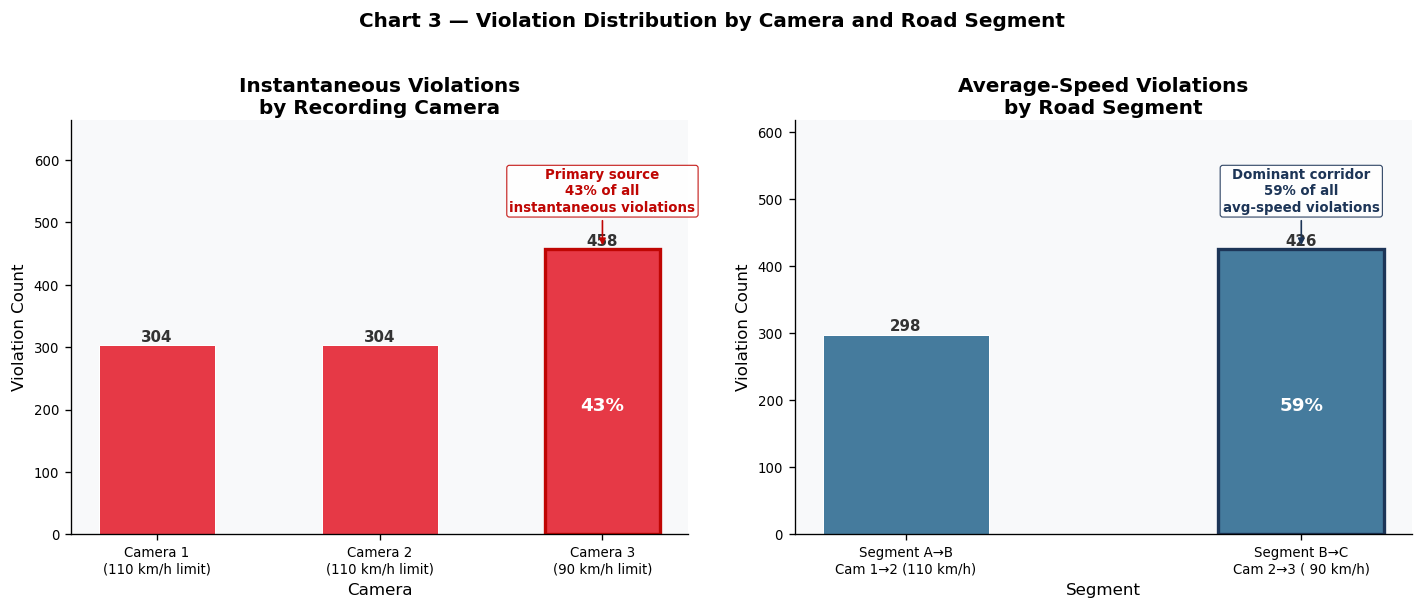

In [7]:
def plot_distribution(
    inst_df: "pd.DataFrame",
    avg_df: "pd.DataFrame",
    save_path: str = "violation_by_camera_segment.png",
    show: bool = True,
) -> "plt.Figure":
    """
    Chart 3 — Violation Distribution by Camera and Road Segment.

    Left panel : instantaneous violation counts by recording camera.
    Right panel : average-speed violation counts by road segment.

    Annotates the dominant camera and segment with explicit analytical callouts
    that state the dominance proportion, making the chart feel analytical rather
    than purely descriptive.

    Parameters
    ----------
    inst_df   : instantaneous violations DataFrame
    avg_df    : average-speed violations DataFrame
    save_path : output PNG path (None to skip saving)
    show      : whether to call plt.show()
    """
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 5))
    fig.subplots_adjust(wspace=0.38)

    # ── Left: instantaneous violations by camera ───────────────────────────────
    cam_counts = (
        inst_df.groupby("camera_id_start").size()
        if not inst_df.empty
        else pd.Series(dtype=int)
    )

    camera_labels = [
        f"Camera {c}\n({CAMERA_META[c]['speed_limit']} km/h limit)"
        for c in sorted(cam_counts.index)
    ] if not cam_counts.empty else []

    bars_l = ax_left.bar(
        camera_labels, cam_counts.values,
        color=COLOUR_INSTANT, edgecolor="white", linewidth=0.6, width=0.52,
    )
    ax_left.grid(False)   # prevent white grid bleeding through bar fill

    # Count labels above each bar
    for bar, val in zip(bars_l, cam_counts.values):
        ax_left.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=9, fontweight="bold",
            color="#333333",
        )

    if not cam_counts.empty and cam_counts.sum() > 0:
        top_cam  = cam_counts.idxmax()
        top_pct  = 100 * cam_counts.max() / cam_counts.sum()
        idx_top  = list(sorted(cam_counts.index)).index(top_cam)

        # Highlight dominant bar with a coloured border
        bars_l[idx_top].set_edgecolor("#BF0603")
        bars_l[idx_top].set_linewidth(2.0)

        # Percentage share badge inside the bar
        ax_left.text(
            idx_top, cam_counts.max() * 0.45,
            f"{top_pct:.0f}%",
            ha="center", va="center", fontsize=11,
            color="white", fontweight="bold",
        )

        # Analytical callout arrow above the dominant bar
        y_callout = cam_counts.max() * 1.12
        ax_left.annotate(
            f"Primary source\n{top_pct:.0f}% of all\ninstantaneous violations",
            xy=(idx_top, cam_counts.max()),
            xytext=(idx_top, y_callout),
            ha="center", va="bottom",
            fontsize=8, color="#BF0603", fontweight="bold",
            arrowprops={**_ANN_ARROW, "color": "#BF0603"},
            bbox={**_ANN_BBOX, "ec": "#BF0603"},
        )

    ax_left.set_title("Instantaneous Violations\nby Recording Camera",
                       pad=4)
    ax_left.set_xlabel("Camera")
    ax_left.set_ylabel("Violation Count")
    ax_left.set_ylim(0, cam_counts.max() * 1.45 if not cam_counts.empty else 1)

    if cam_counts.empty:
        ax_left.text(0.5, 0.5, "No instantaneous\nviolations recorded",
                     transform=ax_left.transAxes, ha="center", va="center",
                     fontsize=12, color="#888")

    # ── Right: average-speed violations by segment ─────────────────────────────
    seg_map = {
        (1, 2): "Segment A→B\nCam 1→2 (110 km/h)",
        (2, 3): "Segment B→C\nCam 2→3 ( 90 km/h)",
    }

    seg_counts = (
        avg_df.groupby(["camera_id_start", "camera_id_end"]).size()
        if not avg_df.empty
        else pd.Series(dtype=int)
    )

    seg_labels = [
        seg_map.get((int(s), int(e)), f"Cam {s}→{e}")
        for s, e in seg_counts.index
    ] if not seg_counts.empty else []

    bars_r = ax_right.bar(
        seg_labels, seg_counts.values,
        color=COLOUR_AVERAGE, edgecolor="white", linewidth=0.6, width=0.42,
    )
    ax_right.grid(False)   # prevent white grid bleeding through bar fill

    for bar, val in zip(bars_r, seg_counts.values):
        ax_right.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=9, fontweight="bold",
            color="#333333",
        )

    if not seg_counts.empty and seg_counts.sum() > 0:
        top_seg_idx = int(seg_counts.values.argmax())
        top_seg_pct = 100 * seg_counts.values.max() / seg_counts.sum()

        bars_r[top_seg_idx].set_edgecolor("#1D3557")
        bars_r[top_seg_idx].set_linewidth(2.0)

        ax_right.text(
            top_seg_idx, seg_counts.values.max() * 0.45,
            f"{top_seg_pct:.0f}%",
            ha="center", va="center", fontsize=11,
            color="white", fontweight="bold",
        )

        # Analytical callout arrow above the dominant segment bar
        y_callout_r = seg_counts.values.max() * 1.12
        ax_right.annotate(
            f"Dominant corridor\n{top_seg_pct:.0f}% of all\navg-speed violations",
            xy=(top_seg_idx, seg_counts.values.max()),
            xytext=(top_seg_idx, y_callout_r),
            ha="center", va="bottom",
            fontsize=8, color="#1D3557", fontweight="bold",
            arrowprops={**_ANN_ARROW, "color": "#1D3557"},
            bbox={**_ANN_BBOX, "ec": "#1D3557"},
        )

    ax_right.set_title("Average-Speed Violations\nby Road Segment", pad=4)
    ax_right.set_xlabel("Segment")
    ax_right.set_ylabel("Violation Count")
    ax_right.set_ylim(0, seg_counts.values.max() * 1.45 if not seg_counts.empty else 1)

    if seg_counts.empty:
        ax_right.text(0.5, 0.5, "No average-speed\nviolations recorded",
                      transform=ax_right.transAxes, ha="center", va="center",
                      fontsize=12, color="#888")

    fig.suptitle("Chart 3 — Violation Distribution by Camera and Road Segment",
                 fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=120)
        print(f"Saved: {save_path}")
    if show:
        plt.show()

    # Expose cam_counts and seg_counts at notebook scope for the summary cell
    global _cam_counts_global, _seg_counts_global
    _cam_counts_global = cam_counts
    _seg_counts_global = seg_counts
    return fig


# ── Static assessed output ────────────────────────────────────────────────────
if SHOW_DISTRIBUTION:
    _dist_fig = plot_distribution(
        inst, avg,
        save_path="violation_by_camera_segment.png",
        show=True,
    )
    # Make cam_counts and seg_counts available to the summary cell
    cam_counts = _cam_counts_global
    seg_counts = _seg_counts_global


## Chart 4 — Violation Type Composition Over Time (Stacked)

**Operational question:** *Are average-speed violations more common than instantaneous violations, and does the mix change over the monitoring period?*

A stacked area chart shows how the composition of violation types evolves over time.
Two annotations are placed using opposite-side logic to avoid overlap:
- **Overall peak** — the period with the highest total violation count.
- **Highest avg share** — the period where average-speed violations form the greatest proportion of the total; operationally significant because these involve cross-segment travel and are harder to contest than single-camera readings.

The shaded region highlights the narrow peak-volume window (±1 period around the all-time peak) for focused operational attention.


Saved: violation_type_proportion_over_time.png


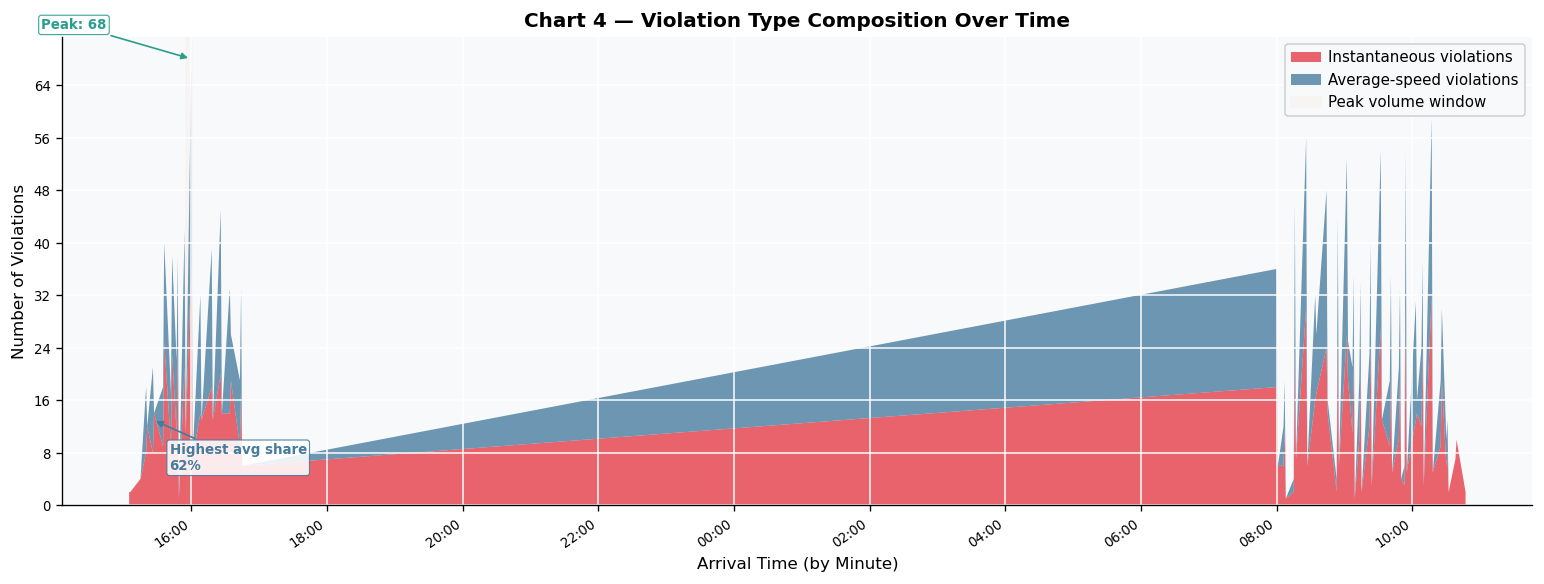

In [8]:
def plot_stacked_composition(
    count_total_s: "pd.Series",
    count_inst_s: "pd.Series",
    count_avg_s: "pd.Series",
    freq_label: str,
    date_fmt: str,
    save_path: str = "violation_type_proportion_over_time.png",
    show: bool = True,
) -> "plt.Figure":
    """
    Chart 4 — Violation Type Composition Over Time (Stacked).

    Stacked area chart showing how the mix of instantaneous vs average-speed
    violations evolves over the monitoring period.

    Key improvements vs the old version:
    - Annotations are placed using _side() logic to avoid left-corner overlap.
    - Peak annotation uses the right half when the peak is near the left edge.
    - Avg-speed share annotation is placed at the blue layer's own height.
    - Shading is subtle (alpha=0.04) and limited to ±1 period around the peak.

    Parameters
    ----------
    count_total_s : total violations per period
    count_inst_s  : instantaneous violations per period
    count_avg_s   : average-speed violations per period
    freq_label    : human-readable grouping frequency (e.g. "Day")
    date_fmt      : strftime format for x-axis labels
    save_path     : output PNG path (None to skip saving)
    show          : whether to call plt.show()
    """
    fig, ax = plt.subplots(figsize=(13, 5))

    all_periods = count_total_s.index
    c_inst = count_inst_s.reindex(all_periods, fill_value=0)
    c_avg  = count_avg_s.reindex(all_periods, fill_value=0)

    ax.stackplot(
        all_periods, c_inst.values, c_avg.values,
        labels=["Instantaneous violations", "Average-speed violations"],
        colors=[COLOUR_INSTANT, COLOUR_AVERAGE],
        alpha=0.78,
    )

    # ── Subtle shading: ±1 period around the single peak only ─────────────────
    if not count_total_s.empty:
        peak_t_s = count_total_s.idxmax()
        peak_idx = list(all_periods).index(peak_t_s)
        shade_lo = all_periods[max(0, peak_idx - 1)]
        shade_hi = all_periods[min(len(all_periods) - 1, peak_idx + 1)]
        ax.axvspan(shade_lo, shade_hi,
                   alpha=0.04, color=COLOUR_SHADE,
                   label="Peak volume window")

    # ── Helper: position in left/right half ───────────────────────────────────
    def _side(idx):
        try:
            pos = list(all_periods).index(idx)
            return "left" if pos < len(all_periods) / 2 else "right"
        except ValueError:
            return "left"

    # ── Annotation 1: overall peak (right-side offset when peak is in left half) ──
    if not count_total_s.empty:
        peak_t_s = count_total_s.idxmax()
        peak_v_s = int(count_total_s.max())
        # Push annotation to the right side of the chart to avoid legend overlap
        off_pk = (10, 18) if _side(peak_t_s) == "right" else (-(90), 18)
        # If the peak is very close to the left edge, always push far right
        pk_pos = list(all_periods).index(peak_t_s) if peak_t_s in all_periods else 0
        if pk_pos < 2:
            off_pk = (10, 18)   # annotate rightward from the point
        _ann(ax, peak_t_s, peak_v_s,
             f"Peak: {peak_v_s}", COLOUR_TOTAL, offset=off_pk)

    # ── Annotation 2: period with highest avg-speed share ─────────────────────
    if c_avg.sum() > 0:
        total_nz   = c_inst + c_avg
        avg_share  = c_avg / total_nz.replace(0, np.nan)
        share_t    = avg_share.idxmax()
        share_v    = avg_share.max()
        # Annotate at the top of the avg-speed (blue) layer at that period
        # Avoid placing near the peak annotation by choosing a different y offset
        y_ann = float(c_avg[share_t])   # height of the blue layer alone
        off_sh = (10, -30) if _side(share_t) == "left" else (-100, -30)
        # If share_t == peak_t_s, offset vertically instead
        if not count_total_s.empty and share_t == count_total_s.idxmax():
            off_sh = (10, -52)
        _ann(ax, share_t, y_ann,
             f"Highest avg share\n{share_v:.0%}",
             COLOUR_AVERAGE, offset=off_sh)

    # ── Formatting ─────────────────────────────────────────────────────────────
    ax.set_title("Chart 4 — Violation Type Composition Over Time")
    ax.set_xlabel(f"Arrival Time (by {freq_label})")
    ax.set_ylabel("Number of Violations")
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    # Legend upper-right: the early spike fills the left, so right is cleaner
    ax.legend(loc="upper right", framealpha=0.88, fontsize=9,
              handlelength=2.0, handletextpad=0.5)
    fig.autofmt_xdate(rotation=35, ha="right")
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=120)
        print(f"Saved: {save_path}")
    if show:
        plt.show()
    return fig


# ── Static assessed output ────────────────────────────────────────────────────
if SHOW_STACKED_COMPOSITION:
    plot_stacked_composition(
        count_total, count_inst, count_avg,
        FREQ_LABEL, DATE_FMT,
        save_path="violation_type_proportion_over_time.png",
        show=True,
    )


---
## Summary — Operational Insights  (Task 2.2.2)

| Plot | Analytical finding | Operational implication |
|---|---|---|
| **Plot 1 — Count over time** | The peak violation period and its exact timestamp are annotated. The surge annotation highlights the largest single-period jump in violations. | Enforcement officers should prioritise patrol resources around the peak period identified. A surge may indicate a special traffic event (e.g. roadworks diversion pushing faster traffic onto this road). |
| **Plot 2 — Speed over time** | The maximum and minimum observed violation speeds are annotated, as well as the sharpest recorded drop in average violation speed across consecutive periods. | A sharp speed drop could indicate a temporary speed camera sign or roadworks warning — worth cross-referencing with operational logs. The maximum speed identifies the highest-risk individual events in the dataset. |
| **Plot 3 — Camera/segment breakdown** | The dominant camera and segment are highlighted with a percentage share badge. | If one segment accounts for the majority of average-speed violations, that corridor's speed limit enforcement or signage should be reviewed. |
| **Plot 4 — Stacked type proportion** | The period with the highest average-speed violation share is annotated. The amber-shaded region highlights the ±1 period window around the all-time peak to focus attention on the busiest interval. | Average-speed violations require a vehicle to be detected at two cameras — periods where they dominate suggest coordinated speeding rather than isolated incidents, which warrants a different enforcement response. |

### Key findings from the dataset


In [9]:

# ── Print a concise summary using the computed series ────────────────────────
total_inst = len(inst)
total_avg  = len(avg)
total_all  = len(df)

peak_t = count_total.idxmax()
peak_v = int(count_total.max())

print("=" * 55)
print("  OPERATIONAL SUMMARY — AWAS Traffic Monitoring")
print("=" * 55)
print(f"  Monitoring period : {df['timestamp_start'].min().date()} → "
      f"{df['timestamp_start'].max().date()}")
print(f"  Total violations  : {total_all:,}")
print(f"    Instantaneous   : {total_inst:,}  ({100*total_inst/total_all:.1f}%)")
print(f"    Average-speed   : {total_avg:,}  ({100*total_avg/total_all:.1f}%)")
print()
print(f"  Peak {FREQ_LABEL.lower():10s}: {peak_t.strftime(DATE_FMT)}  ({peak_v} violations)")
print()

if not combined_speed.empty:
    print(f"  Max violation speed : {combined_speed.max():.1f} km/h")
    print(f"  Min violation speed : {combined_speed.min():.1f} km/h")
    print(f"  Mean violation speed: {df['speed_reading'].mean():.1f} km/h")
print()

if not seg_counts.empty:
    top_seg = seg_counts.idxmax()
    print(f"  Busiest segment     : Cam {top_seg[0]}→{top_seg[1]}  "
          f"({seg_counts.max():,} violations, "
          f"{100*seg_counts.max()/seg_counts.sum():.1f}% of average-speed total)")

if not cam_counts.empty:
    print(f"  Busiest camera      : Camera {cam_counts.idxmax()}  "
          f"({cam_counts.max():,} violations)")

print("=" * 55)


  OPERATIONAL SUMMARY — AWAS Traffic Monitoring
  Monitoring period : 2024-01-01 → 2024-01-02
  Total violations  : 1,790
    Instantaneous   : 1,066  (59.6%)
    Average-speed   : 724  (40.4%)

  Peak minute    : 16:00  (68 violations)

  Max violation speed : 159.2 km/h
  Min violation speed : 91.3 km/h
  Mean violation speed: 129.7 km/h

  Busiest segment     : Cam 2→3  (426 violations, 58.8% of average-speed total)
  Busiest camera      : Camera 3  (458 violations)


## Real-Time Live Monitoring


Starting live monitoring  (max 120 × 5s = 600s).  Press ■ Interrupt Kernel to stop.



'[14:57:34]  Iteration 120/120 — 14,390 violations  |  next refresh in 5s'

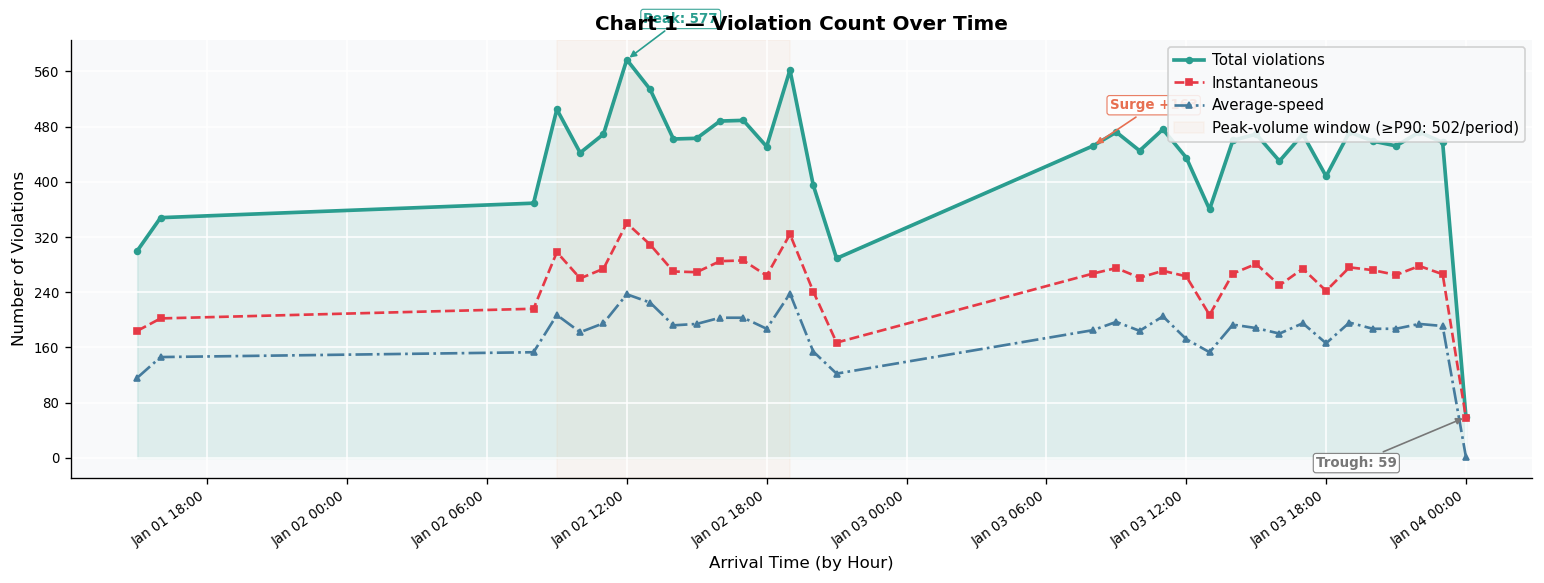

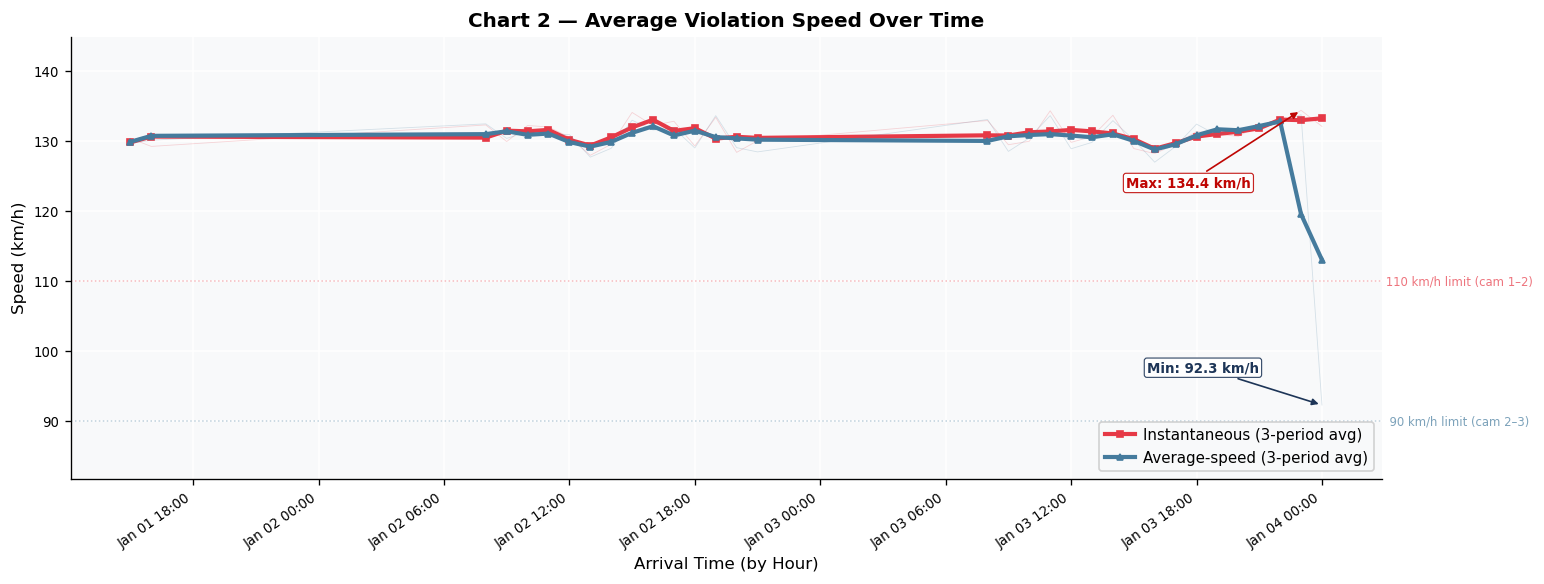

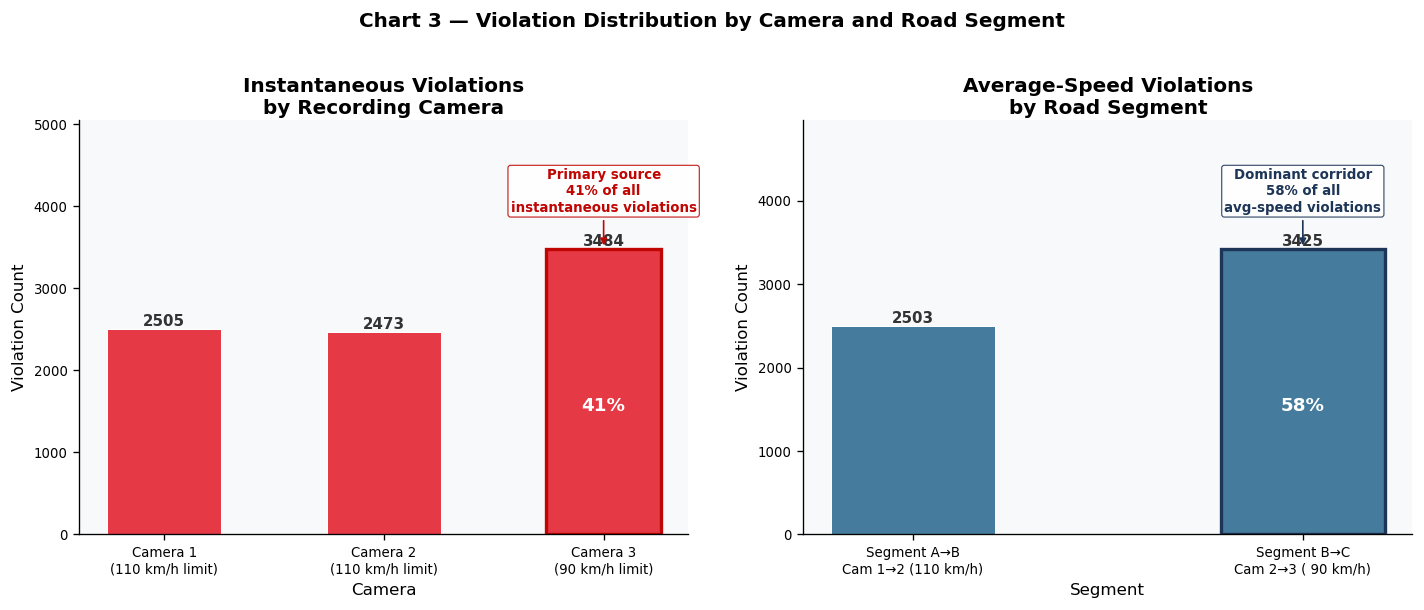

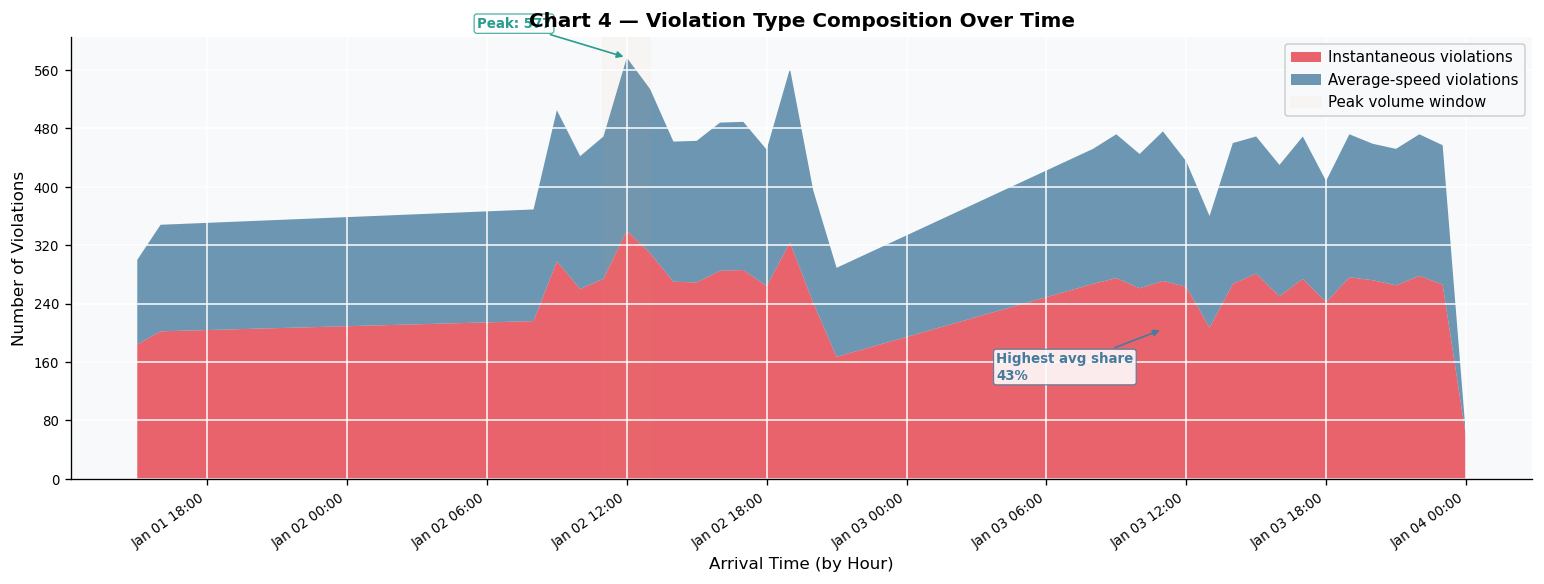

Loaded 1790 violation events from MongoDB (472 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 1790 violation events from MongoDB (472 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 1790 violation events from MongoDB (472 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 2241 violation events from MongoDB (588 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 2241 violation events from MongoDB (588 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_compos

Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 6098 violation events from MongoDB (1528 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 6098 violation events from MongoDB (1528 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 6098 violation events from MongoDB (1528 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 6674 violation events from MongoDB (1667 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 6674 violation events from MongoDB (1667 daily documents).
Saved: ./live_viola

Loaded 10499 violation events from MongoDB (2615 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 10499 violation events from MongoDB (2615 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 10499 violation events from MongoDB (2615 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 10499 violation events from MongoDB (2615 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stacked_composition.png
Loaded 10793 violation events from MongoDB (2738 daily documents).
Saved: ./live_violation_count.png
Saved: ./live_speed_over_time.png
Saved: ./live_distribution.png
Saved: ./live_stac

In [10]:
import time
from IPython.display import display, update_display

# ═══════════════════════════════════════════════════════════════════════════════
#
#  HOW TO ENABLE LIVE MONITORING:
#    1. Set LIVE_MODE = True in the toggle-constants cell (above).
#    2. Run this cell manually (do NOT use "Run All Cells").
#    3. To stop: press ■ (Interrupt Kernel) in Jupyter, or wait until
#       MAX_ITERATIONS refreshes have completed.
#
#  Each enabled chart (SHOW_*) is updated in-place every POLL_INTERVAL seconds
#  using IPython display handles — no full-screen flash between refreshes.
#  Live PNGs are saved to LIVE_SAVE_DIR/.  Static assessed PNGs are unchanged.
#
# ═══════════════════════════════════════════════════════════════════════════════

if not LIVE_MODE:
    print("Live mode is OFF.  "
          "Set LIVE_MODE = True in the toggle-constants cell and re-run to enable.")
else:
    print(f"Starting live monitoring  "
          f"(max {MAX_ITERATIONS} × {POLL_INTERVAL}s = "
          f"{MAX_ITERATIONS * POLL_INTERVAL}s).  "
          f"Press ■ Interrupt Kernel to stop.\n")

    # ── Create one persistent display slot per chart ───────────────────────────
    # Slots are created once here. On each iteration the figure is rendered into
    # its existing slot via update_display(), so the screen never goes blank.
    status_handle = display("Initialising …", display_id="live_status")
    handles = {
        "count":  display(display_id="live_count")       if SHOW_VIOLATION_COUNT     else None,
        "speed":  display(display_id="live_speed")       if SHOW_SPEED_OVER_TIME     else None,
        "dist":   display(display_id="live_dist")        if SHOW_DISTRIBUTION        else None,
        "stack":  display(display_id="live_stack")       if SHOW_STACKED_COMPOSITION else None,
    }

    iteration = 0

    try:
        while iteration < MAX_ITERATIONS:
            iteration += 1
            try:
                # ── 1. Reload violation data from MongoDB ─────────────────────────
                live_df = load_from_mongo()

                for col_name in ("timestamp_start", "timestamp_end"):
                    if live_df[col_name].dt.tz is not None:
                        live_df[col_name] = live_df[col_name].dt.tz_localize(None)

                # ── 2. Adaptive time-grouping ─────────────────────────────────────
                live_span = (live_df["timestamp_start"].max()
                             - live_df["timestamp_start"].min()).days
                if live_span < 1:
                    lfreq, lfreq_label, ldate_fmt = "min", "Minute", "%H:%M"
                elif live_span < 7:
                    lfreq, lfreq_label, ldate_fmt = "h",   "Hour",   "%b %d %H:%M"
                elif live_span < 180:
                    lfreq, lfreq_label, ldate_fmt = "D",   "Day",    "%d %b %Y"
                elif live_span < 5 * 365:
                    lfreq, lfreq_label, ldate_fmt = "ME",  "Month",  "%b %Y"
                else:
                    lfreq, lfreq_label, ldate_fmt = "YE",  "Year",   "%Y"

                live_df["period"] = (live_df["timestamp_start"]
                                     .dt.to_period(lfreq).dt.to_timestamp())

                l_inst = live_df[live_df["violation_type"] == "INSTANTANEOUS"]
                l_avg  = live_df[live_df["violation_type"] == "AVERAGE"]

                l_count_total = live_df.groupby("period").size().rename("count")
                l_count_inst  = l_inst.groupby("period").size().rename("count")
                l_count_avg   = l_avg.groupby("period").size().rename("count")
                l_speed_inst  = l_inst.groupby("period")["speed_reading"].mean()
                l_speed_avg   = l_avg.groupby("period")["avg_speed"].mean()

                # ── 3. Update each chart in-place (no screen flash) ───────────────
                ts = datetime.now().strftime('%H:%M:%S')
                update_display(
                    f"[{ts}]  Iteration {iteration}/{MAX_ITERATIONS} — "
                    f"{len(live_df):,} violations  |  next refresh in {POLL_INTERVAL}s",
                    display_id="live_status",
                )

                if SHOW_VIOLATION_COUNT:
                    fig = plot_violation_count(
                        l_count_total, l_count_inst, l_count_avg,
                        lfreq_label, ldate_fmt,
                        save_path=f"{LIVE_SAVE_DIR}/live_violation_count.png",
                        show=False,
                    )
                    update_display(fig, display_id="live_count")
                    plt.close(fig)

                if SHOW_SPEED_OVER_TIME:
                    fig = plot_speed_over_time(
                        live_df, l_speed_inst, l_speed_avg,
                        lfreq_label, ldate_fmt,
                        save_path=f"{LIVE_SAVE_DIR}/live_speed_over_time.png",
                        show=False,
                    )
                    update_display(fig, display_id="live_speed")
                    plt.close(fig)

                if SHOW_DISTRIBUTION:
                    fig = plot_distribution(
                        l_inst, l_avg,
                        save_path=f"{LIVE_SAVE_DIR}/live_distribution.png",
                        show=False,
                    )
                    update_display(fig, display_id="live_dist")
                    plt.close(fig)

                if SHOW_STACKED_COMPOSITION:
                    fig = plot_stacked_composition(
                        l_count_total, l_count_inst, l_count_avg,
                        lfreq_label, ldate_fmt,
                        save_path=f"{LIVE_SAVE_DIR}/live_stacked_composition.png",
                        show=False,
                    )
                    update_display(fig, display_id="live_stack")
                    plt.close(fig)

            except Exception as exc:
                ts = datetime.now().strftime('%H:%M:%S')
                update_display(
                    f"[{ts}]  Warning: refresh failed — {exc}  (retrying in {POLL_INTERVAL}s)",
                    display_id="live_status",
                )

            time.sleep(POLL_INTERVAL)

    except KeyboardInterrupt:
        print("\nKeyboard interrupt received. Stopping live monitoring …")
    finally:
        print("Live monitoring stopped.")

    if iteration >= MAX_ITERATIONS:
        print(f"Live monitoring reached MAX_ITERATIONS ({MAX_ITERATIONS}).  "
              "Increase MAX_ITERATIONS in the toggle-constants cell or re-run to continue.")
